# Heat-kernel IP vs recursive IP on the CM grid

Both notebooks `heatK_vs_sir_scatter_grid_cm.ipynb` and `recursiveIP_vs_sir_scatter_grid_cm.ipynb` compare a node-level infection-probability estimate against the SIR Monte-Carlo $P(\text{infected})$ on the same configuration-model grid, with the same calibrated $\beta$. They only differ in the estimator:

- **HKd**: $\mathrm{HKd}(v) = 1 - [e^{-tL}]_{vv}$ with $t = \beta/\gamma$ and $L = D - W$ (proximity Laplacian).
- **RIP**: fixed point of $p_v \leftarrow 1 - \prod_{u\sim v}(1 - p_u\, q_{uv})$ with $q_{uv} = \tfrac{\beta w_{uv}}{\beta w_{uv} + \gamma}$, starting from $p_v = 1/n$.

At small $\beta/\gamma$ both linearize to a degree-weighted quantity (HKd $\approx t\,\deg(v)$ at first order; one Jacobi step of RIP at $p\!=\!0$ gives $p_v \approx \sum_u q_{uv}\,p_u$ with $q \to \beta w/\gamma$), so we expect them to collapse onto a common curve in that regime and separate as $\beta$ grows / the graph approaches the epidemic threshold.

This notebook does two things:
1. **Grid scatter**: for each (degree, weight) cell, plot HKd vs RIP on the original graph with the $y=x$ diagonal, annotated with Pearson correlations against each other and against $P_{\rm SIR}$.
2. **$\beta$-sweep**: on one fixed graph, sweep $\beta$ from small to above the calibrated value and track $\rho(\mathrm{HKd},\mathrm{RIP})$, $\mathrm{MSE}(\mathrm{HKd},\mathrm{RIP})$ and the mean level of each estimator.

In [1]:
import sys
from pathlib import Path

for _root in (Path.cwd().resolve(), Path.cwd().resolve().parent):
    _py = _root / "src" / "python"
    if _py.is_dir():
        sys.path.insert(0, str(_py.resolve()))
        break

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy import sparse
import scipy.sparse.linalg as _sla
from tqdm.auto import tqdm

from graph_sparsification.generators import configuration_model
from graph_sparsification.sir import sir_monte_carlo, calibrate_beta

if not hasattr(_sla, "_cg_orig"):
    _sla._cg_orig = _sla.cg


def _cg_compat(A, b, *args, **kwargs):
    if "tol" in kwargs:
        kwargs["rtol"] = kwargs.pop("tol")
    return _sla._cg_orig(A, b, *args, **kwargs)


_sla.cg = _cg_compat


def normalize_proximity_csr(W, prev_scale=1.0):
    W = sparse.csr_matrix(W, dtype=float).copy()
    if W.nnz == 0:
        return W, float(prev_scale)
    mx = float(W.data.max())
    if mx <= 0:
        return W, float(prev_scale)
    W.data = np.clip(W.data / mx, 1e-12, 1.0 - 1e-12)
    return W, float(prev_scale * mx)


def generate_config_model(n, degree_dist, weight_dist, seed=None):
    rng = np.random.default_rng(seed)

    def degree_sampler(nn, r):
        return np.asarray(degree_dist(nn), dtype=int)

    def weight_sampler(m, r):
        return np.asarray(weight_dist(m), dtype=float)

    W = configuration_model(n, degree_sampler, weight_sampler, rng=rng)
    W, _ = normalize_proximity_csr(W, 1.0)
    return W


def heat_kernel_diag(W_prox, beta, gamma, t=None):
    W = sparse.csr_matrix(W_prox, dtype=np.float64).toarray()
    n = W.shape[0]
    if n == 0:
        return np.zeros(0, dtype=np.float64)
    if not np.any(W):
        return np.zeros(n, dtype=np.float64)
    deg = W.sum(axis=1).ravel()
    L = np.diag(deg) - W
    L = 0.5 * (L + L.T)
    t_use = (float(beta) / float(gamma)) if (t is None and gamma > 0) else (float(beta) if t is None else float(t))
    evals, V = np.linalg.eigh(L)
    d = np.exp(-t_use * evals)
    hk_diag = np.sum((V * V) * d, axis=1)
    return 1.0 - hk_diag


def recursive_ip(W_prox, beta, gamma, max_iter=2000, tol=1e-8):
    W = sparse.csr_matrix(W_prox, dtype=float)
    n = W.shape[0]
    if n == 0:
        return np.zeros(0), 0, True
    beta = float(beta)
    gamma = float(gamma)
    coo = W.tocoo()
    rows = coo.row.astype(np.int64)
    cols = coo.col.astype(np.int64)
    wvals = coo.data.astype(np.float64)
    denom = beta * wvals + gamma
    qvals = np.where(denom > 0, beta * wvals / denom, 0.0)

    p = np.full(n, 1.0 / n, dtype=np.float64)
    converged = False
    it_done = 0
    for it in range(max_iter):
        terms = 1.0 - p[rows] * qvals
        np.clip(terms, 1e-300, 1.0, out=terms)
        log_terms = np.log(terms)
        log_prod = np.zeros(n, dtype=np.float64)
        np.add.at(log_prod, cols, log_terms)
        p_new = 1.0 - np.exp(log_prod)
        np.clip(p_new, 0.0, 1.0, out=p_new)
        diff = float(np.max(np.abs(p_new - p)))
        p = p_new
        it_done = it + 1
        if diff < tol:
            converged = True
            break
    return p, it_done, converged


def run_sir_original(W, beta, gamma, patient_zeros, t_max, n_runs, seed):
    rng = np.random.default_rng(seed)
    res = sir_monte_carlo(
        sparse.csr_matrix(W, dtype=float),
        float(beta),
        float(gamma),
        initial_infected=patient_zeros,
        n_runs=int(n_runs),
        t_max=float(t_max),
        rng=rng,
        use_cpp=True,
    )
    return res["infection_prob"]


def calibrate_beta_notebook(W_prox, sir_gamma, sir_patient_zeros, sir_t_max, seed,
                            target_range=(0.45, 0.7), start_beta=1.0,
                            beta_low=0.001, beta_high=1000.0, max_iters=20,
                            n_probe_runs=20, verbose=False):
    rng = np.random.default_rng(seed)
    beta, info = calibrate_beta(
        sparse.csr_matrix(W_prox, dtype=float),
        gamma=float(sir_gamma),
        target_range=target_range,
        initial_infected=sir_patient_zeros,
        n_calibration_runs=int(n_probe_runs),
        t_max=float(sir_t_max),
        rng=rng,
        beta_min=float(beta_low),
        beta_max=float(beta_high),
        max_iterations=int(max_iters),
        verbose=verbose,
        start_beta=float(start_beta),
    )
    return beta, float(info["mean_infection"])


def _rho(x, y):
    if np.std(x) > 1e-15 and np.std(y) > 1e-15:
        return float(np.corrcoef(x, y)[0, 1])
    return float("nan")


In [2]:
# --- Match heatK_vs_sir_scatter_grid_cm / recursiveIP_vs_sir_scatter_grid_cm defaults ---
n_nodes = 500
sir_gamma = 1.0
sir_t_max = 100.0
sir_n_runs = 1000
sir_patient_zeros = 0.01  # fraction: random 1% seeds per run

rip_max_iter = 2000
rip_tol = 1e-8

# Restrict grid for quick runs (use slice(None) for full grid)
CM_ROW_SLICE = slice(None)
CM_COL_SLICE = slice(None)


## Configuration model grid: HKd vs RIP per cell

Each panel shows one (degree, weight) configuration. Dots are nodes; $x$ is HKd$(v)$, $y$ is RIP$(v)$; the dashed line is $y=x$. The title reports $\beta$ (calibrated), the Pearson $\rho(\mathrm{HKd},\mathrm{RIP})$, and — for context — the Pearson correlations of each estimator with the SIR $P(\text{infected})$ on the original graph.

In [3]:
degree_configs = [
    ("Unif(1,50)", lambda n: np.maximum(1, np.minimum(n - 1, np.random.randint(1, 51, n)))),
    ("Unif(1,100)", lambda n: np.maximum(1, np.minimum(n - 1, np.random.randint(1, 101, n)))),
    ("Exp(scale=30)", lambda n: np.maximum(1, np.minimum(n - 1, np.ceil(np.random.exponential(30, n)).astype(int)))),
    ("Exp(scale=60)", lambda n: np.maximum(1, np.minimum(n - 1, np.ceil(np.random.exponential(60, n)).astype(int)))),
    ("LogNorm(\u03bc=3.26,\u03c3=0.66)", lambda n: np.maximum(1, np.minimum(n - 1, np.round(np.exp(np.random.normal(3.26, 0.66, n))).astype(int)))),
    ("LogNorm(\u03bc=3.26,\u03c3=2)", lambda n: np.maximum(1, np.minimum(n - 1, np.round(np.exp(np.random.normal(3.26, 2, n))).astype(int)))),
    ("Pareto(\u03b1=2.5,\u03c3=20)", lambda n: np.maximum(1, np.minimum(n - 1, np.round(stats.pareto.rvs(b=2.5, scale=20, size=n)).astype(int)))),
    ("Pareto(\u03b1=1.5,\u03c3=30)", lambda n: np.maximum(1, np.minimum(n - 1, np.round(stats.pareto.rvs(b=1.5, scale=30, size=n)).astype(int)))),
]

weight_configs = [
    ("Exp(1/30)", lambda m: np.maximum(1e-9, np.random.exponential(1 / 30, m))),
    ("Exp(1)", lambda m: np.maximum(1e-9, np.random.exponential(1, m))),
    ("Exp(30)", lambda m: np.maximum(1e-9, np.random.exponential(30, m))),
    ("LogNorm(2,1)", lambda m: np.maximum(1e-9, np.random.lognormal(2, 1, m))),
    ("LogLogNorm(1.2,0.4)", lambda m: np.maximum(1e-9, np.exp(np.exp(np.random.normal(1.2, 0.4, m))))),
    ("LogLogNorm(1.2,0.8)", lambda m: np.maximum(1e-9, np.exp(np.exp(np.random.normal(1.2, 0.8, m))))),
    ("LogLogNorm(2,0.8)", lambda m: np.maximum(1e-9, np.exp(np.exp(np.random.normal(2, 0.8, m))))),
]


CM grid:   0%|          | 0/56 [00:00<?, ?it/s]

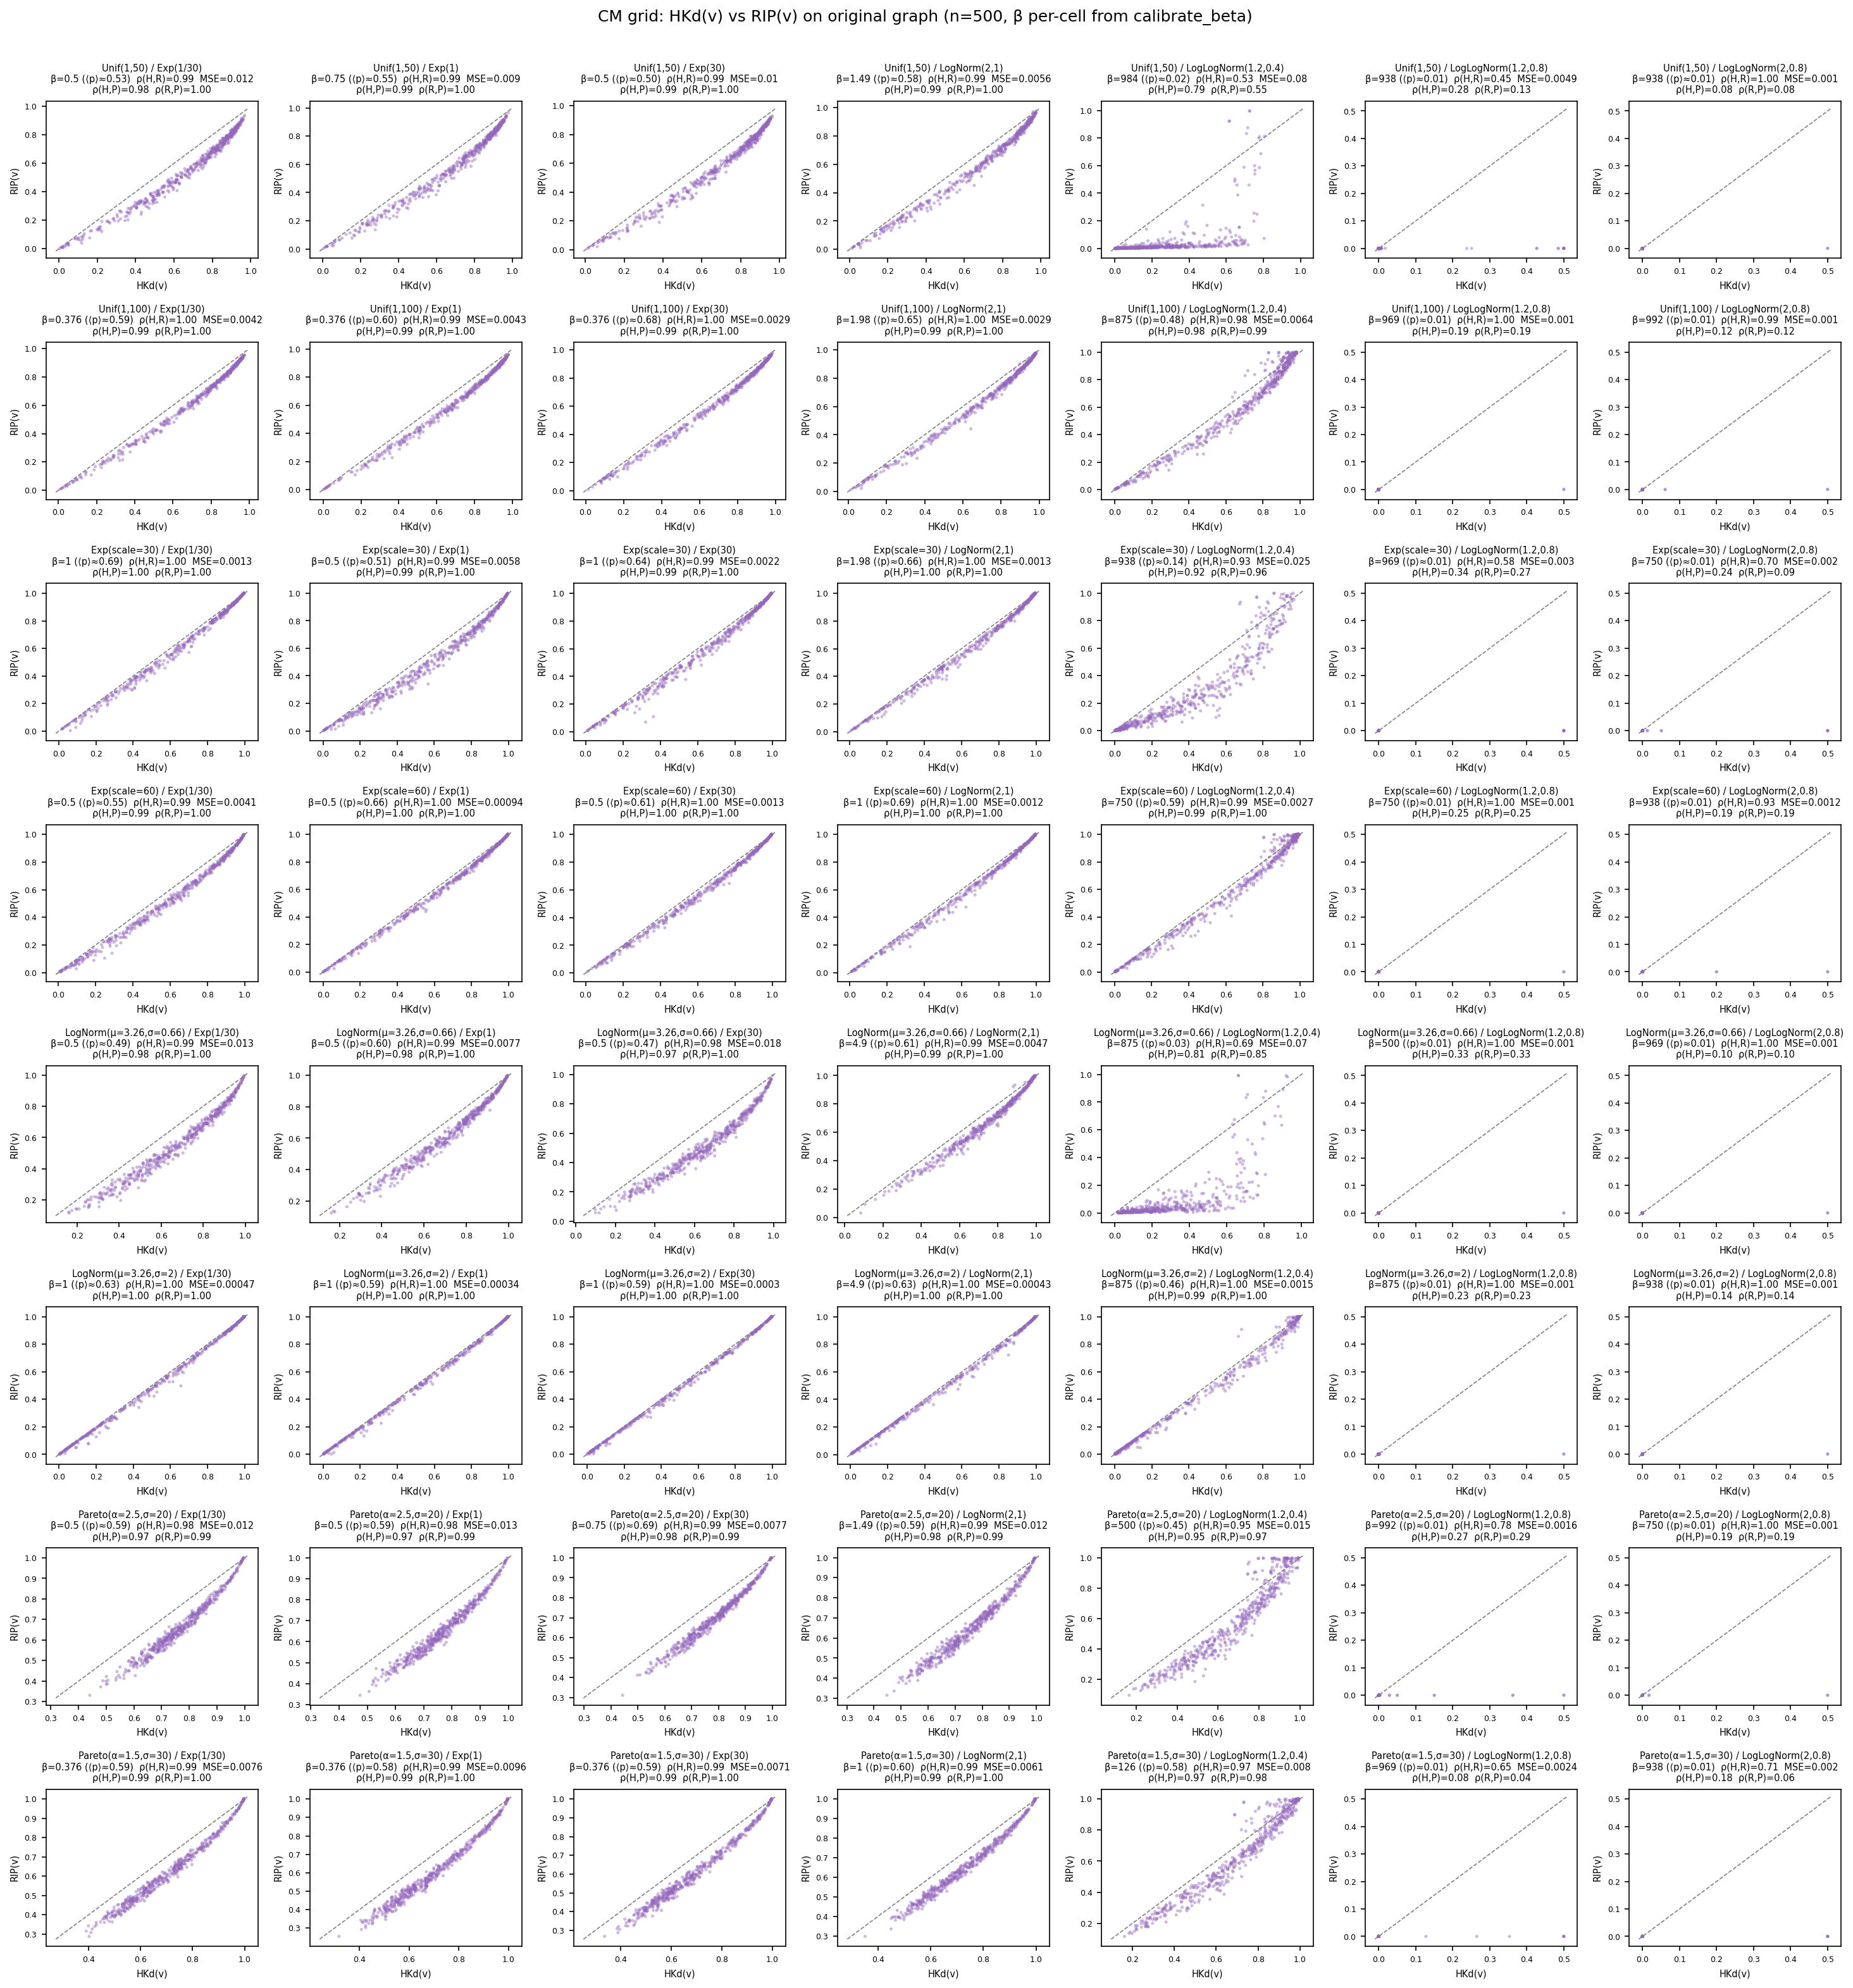

Pearson ρ(HKd, RIP) per panel (rows=degree, cols=weight):
[[0.989 0.99  0.99  0.993 0.528 0.448 1.   ]
 [0.995 0.995 0.996 0.995 0.981 1.    0.993]
 [0.997 0.991 0.995 0.997 0.935 0.575 0.704]
 [0.995 0.998 0.997 0.997 0.992 1.    0.928]
 [0.985 0.988 0.981 0.99  0.693 1.    1.   ]
 [0.999 0.999 0.999 0.999 0.996 1.    1.   ]
 [0.984 0.982 0.989 0.985 0.953 0.783 0.999]
 [0.99  0.989 0.991 0.991 0.971 0.649 0.706]]

Pearson ρ(HKd, P_SIR):
[[0.985 0.985 0.986 0.99  0.792 0.276 0.079]
 [0.993 0.993 0.994 0.994 0.977 0.193 0.122]
 [0.996 0.989 0.993 0.995 0.923 0.342 0.243]
 [0.993 0.997 0.996 0.996 0.991 0.253 0.191]
 [0.98  0.984 0.974 0.986 0.806 0.326 0.1  ]
 [0.998 0.999 0.999 0.999 0.995 0.227 0.141]
 [0.972 0.971 0.979 0.976 0.947 0.268 0.192]
 [0.986 0.986 0.987 0.985 0.971 0.08  0.181]]

Pearson ρ(RIP, P_SIR):
[[0.998 0.998 0.998 0.999 0.555 0.131 0.079]
 [0.999 0.998 0.999 0.999 0.99  0.193 0.117]
 [0.999 0.999 0.999 0.999 0.963 0.272 0.093]
 [0.999 0.999 0.999 0.999 0.997 0.253

In [4]:
def scatter_hkd_vs_rip(hkd, rip, ax, title, fontsize=7):
    kw = dict(s=6, alpha=0.45, edgecolors="none", rasterized=True)
    ax.scatter(hkd, rip, c="tab:purple", **kw)
    lo = float(min(hkd.min(), rip.min()))
    hi = float(max(hkd.max(), rip.max()))
    pad = 0.02 * (hi - lo + 1e-9)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], c="0.5", lw=0.8, ls="--", zorder=0)
    ax.set_xlabel("HKd(v)", fontsize=fontsize)
    ax.set_ylabel("RIP(v)", fontsize=fontsize)
    ax.set_title(title, fontsize=fontsize)
    ax.tick_params(labelsize=fontsize - 1)
    return _rho(hkd, rip)


row_idx = list(range(len(degree_configs)))[CM_ROW_SLICE]
col_idx = list(range(len(weight_configs)))[CM_COL_SLICE]
n_r, n_c = len(row_idx), len(col_idx)

fig_cm, axes_cm = plt.subplots(n_r, n_c, figsize=(2.8 * n_c, 2.6 * n_r), squeeze=False, dpi=150)
rho_hr = np.full((n_r, n_c), np.nan)      # rho(HKd, RIP)
rho_h_p = np.full((n_r, n_c), np.nan)     # rho(HKd, P_SIR)
rho_r_p = np.full((n_r, n_c), np.nan)     # rho(RIP, P_SIR)
mse_hr = np.full((n_r, n_c), np.nan)      # MSE(HKd, RIP)
beta_grid = np.full((n_r, n_c), np.nan)
mean_p_cal_grid = np.full((n_r, n_c), np.nan)

tasks = [(ii, i, jj, j) for ii, i in enumerate(row_idx) for jj, j in enumerate(col_idx)]

for ii, i, jj, j in tqdm(tasks, desc="CM grid"):
    deg_label, degree_dist = degree_configs[i]
    wgt_label, weight_dist = weight_configs[j]
    W = generate_config_model(n_nodes, degree_dist, weight_dist, seed=42 + i * 10 + j)
    W = sparse.csr_matrix(W, dtype=float)

    cal_seed = 1000 + i * 10 + j
    beta, mean_p_cal = calibrate_beta_notebook(
        W, sir_gamma, sir_patient_zeros, sir_t_max, cal_seed,
        target_range=(0.45, 0.7), start_beta=1.0,
        beta_low=0.001, beta_high=1000.0, max_iters=20, n_probe_runs=20,
    )
    beta_grid[ii, jj] = beta
    mean_p_cal_grid[ii, jj] = mean_p_cal

    hkd = heat_kernel_diag(W, beta, sir_gamma)
    rip, it_r, cv_r = recursive_ip(W, beta, sir_gamma, max_iter=rip_max_iter, tol=rip_tol)
    p_orig = run_sir_original(W, beta, sir_gamma, sir_patient_zeros, sir_t_max, sir_n_runs, seed=cal_seed + 10_000)

    mse_hr[ii, jj] = float(np.mean((hkd - rip) ** 2))
    rho_h_p[ii, jj] = _rho(hkd, p_orig)
    rho_r_p[ii, jj] = _rho(rip, p_orig)

    title = (
        f"{deg_label} / {wgt_label}\n"
        f"\u03b2={beta:.3g} (\u27e8p\u27e9\u2248{mean_p_cal:.2f})  "
        f"\u03c1(H,R)={_rho(hkd, rip):.2f}  MSE={mse_hr[ii, jj]:.2g}\n"
        f"\u03c1(H,P)={rho_h_p[ii, jj]:.2f}  \u03c1(R,P)={rho_r_p[ii, jj]:.2f}"
    )
    rho_hr[ii, jj] = scatter_hkd_vs_rip(hkd, rip, axes_cm[ii, jj], title)

fig_cm.suptitle(
    f"CM grid: HKd(v) vs RIP(v) on original graph (n={n_nodes}, \u03b2 per-cell from calibrate_beta)",
    y=1.005,
)
fig_cm.tight_layout()
plt.show()

print("Pearson \u03c1(HKd, RIP) per panel (rows=degree, cols=weight):")
print(np.round(rho_hr, 3))
print("\nPearson \u03c1(HKd, P_SIR):")
print(np.round(rho_h_p, 3))
print("\nPearson \u03c1(RIP, P_SIR):")
print(np.round(rho_r_p, 3))
print("\nMSE(HKd, RIP):")
print(np.round(mse_hr, 4))


### Does the calibrated $\beta$ predict the gap between HKd and RIP?

If the two estimators agree in the small-$\beta$ regime and separate as $\beta$ grows, per-panel MSE(HKd, RIP) should rise with $\beta$. The plot below checks this across the CM grid.

grid points: 56
β range: [0.376, 992]
Pearson(β, MSE)         = 0.153
Pearson(log10 β, MSE)   = 0.125
Spearman(β, MSE)        = -0.306


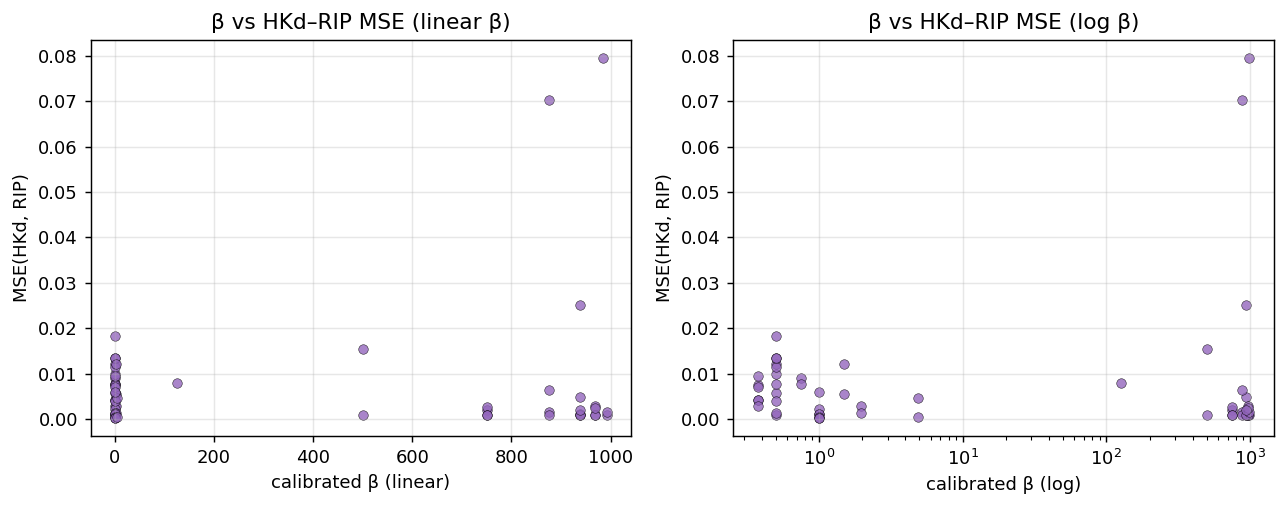

In [5]:
betas = beta_grid.ravel()
mse_flat = mse_hr.ravel()
m = np.isfinite(betas) & np.isfinite(mse_flat) & (betas > 0)
b = betas[m]; y = mse_flat[m]

r_lin = _rho(b, y)
r_log = _rho(np.log10(b), y)
rho_s, _ = stats.spearmanr(b, y) if b.size >= 2 else (float("nan"), None)
print(f"grid points: {b.size}")
print(f"\u03b2 range: [{b.min():.3g}, {b.max():.3g}]")
print(f"Pearson(\u03b2, MSE)         = {r_lin:.3f}")
print(f"Pearson(log10 \u03b2, MSE)   = {r_log:.3f}")
print(f"Spearman(\u03b2, MSE)        = {float(rho_s):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=130)
for ax, xscale in zip(axes, ("linear", "log")):
    ax.scatter(b, y, c="tab:purple", s=28, alpha=0.8, edgecolors="k", linewidths=0.3)
    ax.set_xscale(xscale)
    ax.set_xlabel(f"calibrated \u03b2 ({xscale})")
    ax.set_ylabel("MSE(HKd, RIP)")
    ax.set_title(f"\u03b2 vs HKd\u2013RIP MSE ({xscale} \u03b2)")
    ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## $\beta$-sweep on one fixed CM graph

Fix one (degree, weight) pair and vary $\beta$ over several decades around its calibrated value. For each $\beta$ we compute HKd and RIP and report:

- $\rho(\mathrm{HKd},\mathrm{RIP})$ — node-level correlation.
- $\mathrm{MSE}(\mathrm{HKd},\mathrm{RIP})$ — how far the scatter departs from $y=x$.
- $\overline{\mathrm{HKd}}$ and $\overline{\mathrm{RIP}}$ — mean level of each estimator.

The expectation: at the smallest $\beta$ both collapse to the same degree-weighted profile (high $\rho$, low MSE, both means $\to 0$); at the largest $\beta$ HKd saturates toward 1 across all nodes while RIP can sit at its fixed point with much more dispersion.

Calibrated β on this cell = 1  (⟨p⟩≈0.66)


β sweep:   0%|          | 0/25 [00:00<?, ?it/s]

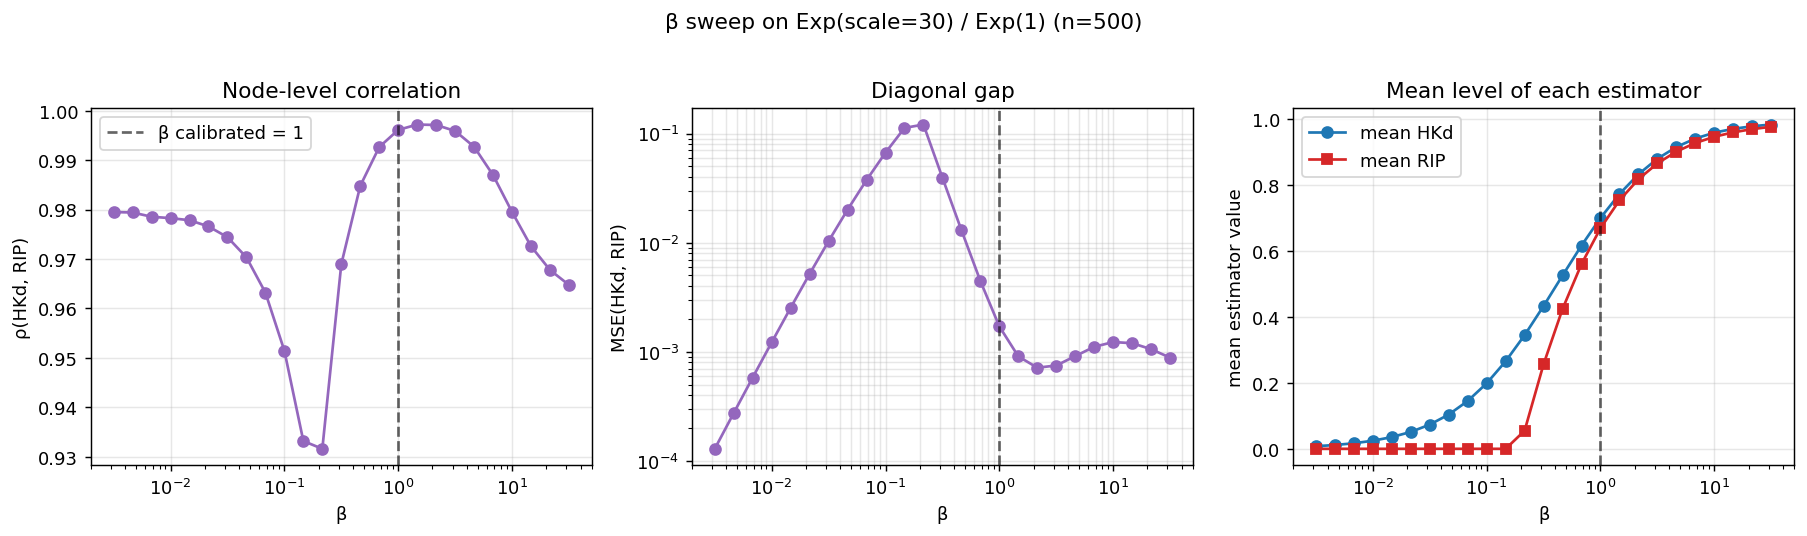

In [6]:
# Pick one representative cell (Exp(scale=30) / Exp(1)).
sweep_i, sweep_j = 2, 1
deg_label, degree_dist = degree_configs[sweep_i]
wgt_label, weight_dist = weight_configs[sweep_j]
W_sweep = generate_config_model(n_nodes, degree_dist, weight_dist, seed=42 + sweep_i * 10 + sweep_j)
W_sweep = sparse.csr_matrix(W_sweep, dtype=float)

cal_seed = 1000 + sweep_i * 10 + sweep_j
beta_cal, mean_p_cal = calibrate_beta_notebook(
    W_sweep, sir_gamma, sir_patient_zeros, sir_t_max, cal_seed,
    target_range=(0.45, 0.7),
)
print(f"Calibrated \u03b2 on this cell = {beta_cal:.4g}  (\u27e8p\u27e9\u2248{mean_p_cal:.2f})")

# Sweep across ~3 decades around the calibrated value.
betas_sweep = beta_cal * np.logspace(-2.5, 1.5, 25)

rho_sweep = np.full(betas_sweep.size, np.nan)
mse_sweep = np.full(betas_sweep.size, np.nan)
mean_hkd = np.full(betas_sweep.size, np.nan)
mean_rip = np.full(betas_sweep.size, np.nan)

for k, bk in enumerate(tqdm(betas_sweep, desc="\u03b2 sweep")):
    hkd = heat_kernel_diag(W_sweep, bk, sir_gamma)
    rip, _, _ = recursive_ip(W_sweep, bk, sir_gamma, max_iter=rip_max_iter, tol=rip_tol)
    rho_sweep[k] = _rho(hkd, rip)
    mse_sweep[k] = float(np.mean((hkd - rip) ** 2))
    mean_hkd[k] = float(np.mean(hkd))
    mean_rip[k] = float(np.mean(rip))

fig, axes = plt.subplots(1, 3, figsize=(14, 4), dpi=130)

axes[0].plot(betas_sweep, rho_sweep, marker="o", c="tab:purple")
axes[0].axvline(beta_cal, ls="--", c="k", alpha=0.6, label=f"\u03b2 calibrated = {beta_cal:.3g}")
axes[0].set_xscale("log")
axes[0].set_xlabel("\u03b2")
axes[0].set_ylabel("\u03c1(HKd, RIP)")
axes[0].set_title("Node-level correlation")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(betas_sweep, mse_sweep, marker="o", c="tab:purple")
axes[1].axvline(beta_cal, ls="--", c="k", alpha=0.6)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("\u03b2")
axes[1].set_ylabel("MSE(HKd, RIP)")
axes[1].set_title("Diagonal gap")
axes[1].grid(True, alpha=0.3, which="both")

axes[2].plot(betas_sweep, mean_hkd, marker="o", label="mean HKd", c="tab:blue")
axes[2].plot(betas_sweep, mean_rip, marker="s", label="mean RIP", c="tab:red")
axes[2].axvline(beta_cal, ls="--", c="k", alpha=0.6)
axes[2].set_xscale("log")
axes[2].set_xlabel("\u03b2")
axes[2].set_ylabel("mean estimator value")
axes[2].set_title("Mean level of each estimator")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

fig.suptitle(f"\u03b2 sweep on {deg_label} / {wgt_label} (n={n_nodes})", y=1.02)
fig.tight_layout()
plt.show()


### Scatter snapshots along the sweep

A small gallery of HKd-vs-RIP scatters at five $\beta$ values along the sweep, showing the transition from collapse onto $y=x$ (low $\beta$) to separation (high $\beta$, HKd saturates).

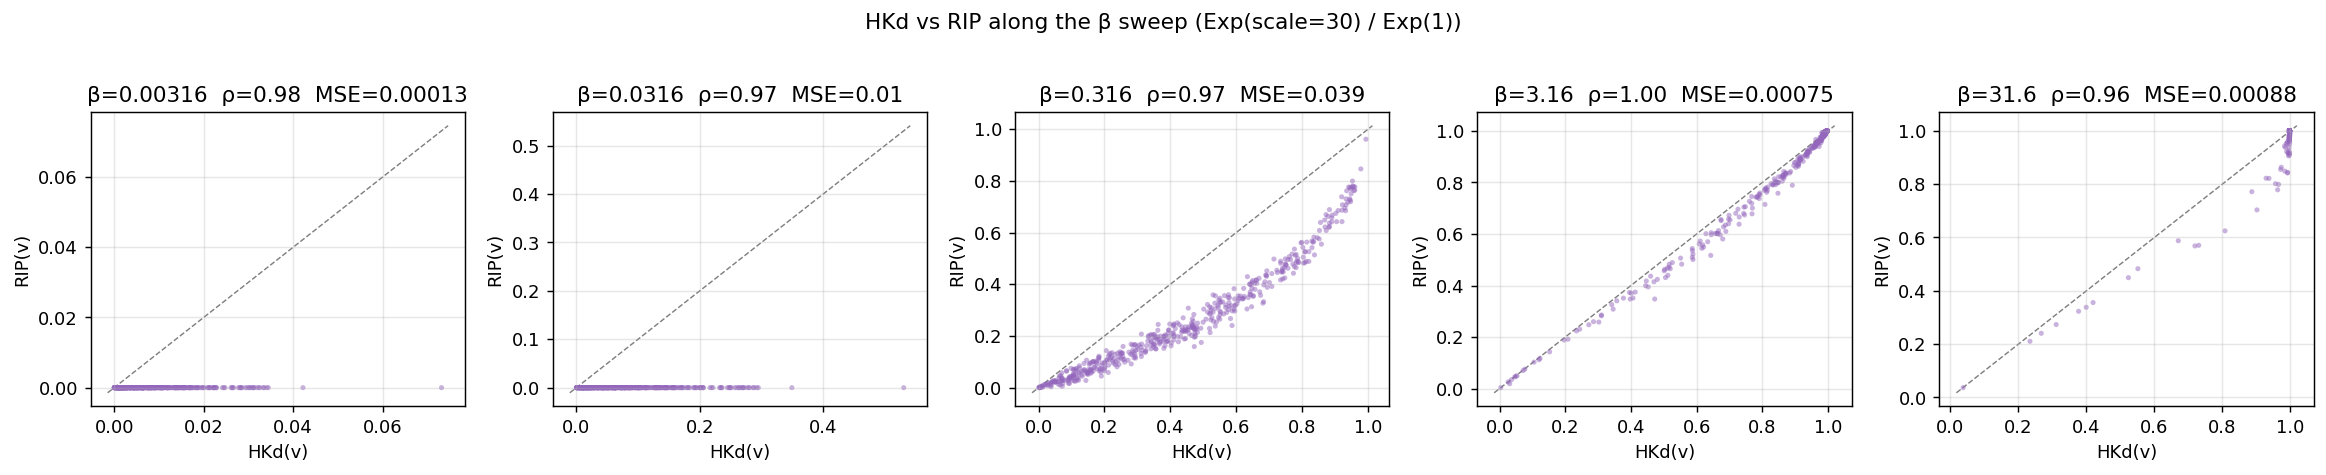

In [7]:
snap_idx = np.linspace(0, betas_sweep.size - 1, 5).astype(int)
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5), dpi=130, squeeze=False)
for ax, k in zip(axes[0], snap_idx):
    bk = betas_sweep[k]
    hkd = heat_kernel_diag(W_sweep, bk, sir_gamma)
    rip, _, _ = recursive_ip(W_sweep, bk, sir_gamma, max_iter=rip_max_iter, tol=rip_tol)
    ax.scatter(hkd, rip, s=8, alpha=0.5, c="tab:purple", edgecolors="none", rasterized=True)
    lo = float(min(hkd.min(), rip.min()))
    hi = float(max(hkd.max(), rip.max()))
    pad = 0.02 * (hi - lo + 1e-9)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], c="0.5", lw=0.8, ls="--", zorder=0)
    ax.set_xlabel("HKd(v)")
    ax.set_ylabel("RIP(v)")
    ax.set_title(f"\u03b2={bk:.3g}  \u03c1={_rho(hkd, rip):.2f}  MSE={float(np.mean((hkd - rip) ** 2)):.2g}")
    ax.grid(True, alpha=0.3)
fig.suptitle(f"HKd vs RIP along the \u03b2 sweep ({deg_label} / {wgt_label})", y=1.03)
fig.tight_layout()
plt.show()
